## Sportmonks Germany 201 — 05: Synthesis

Merge per-principle feature tables (notebooks 02–04) on `fixture_id`, then compare **competitions** and inspect **bivariate structure** (correlation among proxies).

Prerequisite CSVs in `sportmonks/`: `germany_pressing_features.csv`, `germany_attacking_features.csv`, `germany_defensive_features.csv` (and `fixtures_germany_201.csv` for context).

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if (ROOT / "sportmonks").is_dir():
    SPORTMONKS_DIR = ROOT / "sportmonks"
    sys.path.insert(0, str(SPORTMONKS_DIR))
else:
    SPORTMONKS_DIR = ROOT
    sys.path.insert(0, str(ROOT))

In [8]:
press = pd.read_csv(SPORTMONKS_DIR / "germany_pressing_features.csv", parse_dates=["starting_at"])
atk = pd.read_csv(SPORTMONKS_DIR / "germany_attacking_features.csv", parse_dates=["starting_at"])
defe = pd.read_csv(SPORTMONKS_DIR / "germany_defensive_features.csv", parse_dates=["starting_at"])

atk_n = atk.drop(columns=["starting_at", "league_id"], errors="ignore")
defe_n = defe.drop(columns=["starting_at", "league_id"], errors="ignore")
m = press.merge(atk_n, on="fixture_id").merge(defe_n, on="fixture_id")
m["competition"] = m["league_id"].map(
    {1326: "Euro 2024", 1538: "Nations League 25", 720: "WCQ Europe"}
).fillna(m["league_id"].astype(str))
m.head()

,fixture_id,starting_at,league_id,ger_tackles_x,ger_interceptions_x,ger_clearances_x,ger_blocks_x,ger_fouls_x,ger_ball_recoveries,defensive_actions_sum,...,xg_for_germany,ger_tackles_y,ger_interceptions_y,ger_clearances_y,ger_blocks_y,ger_saves,ger_fouls_y,defensive_compact_sum,formation_label,competition
0,19032613,2024-06-14 19:00:00,1326,10.0,2.0,NaN,5.0,15.0,NaN,17.0,...,NaN,10.0,2.0,NaN,5.0,0.0,15.0,17.0,4-2-3-1,Euro 2024
1,19032614,2024-06-19 16:00:00,1326,17.0,6.0,NaN,7.0,12.0,NaN,30.0,...,NaN,17.0,6.0,NaN,7.0,3.0,12.0,33.0,4-2-3-1,Euro 2024
2,19032615,2024-06-23 19:00:00,1326,17.0,7.0,NaN,5.0,12.0,NaN,29.0,...,NaN,17.0,7.0,NaN,5.0,2.0,12.0,31.0,4-2-3-1,Euro 2024
3,19032605,2024-06-29 19:00:00,1326,7.0,8.0,NaN,1.0,7.0,NaN,16.0,...,NaN,7.0,8.0,NaN,1.0,2.0,7.0,18.0,4-2-3-1,Euro 2024
4,19032601,2024-07-05 16:00:00,1326,23.0,9.0,NaN,7.0,22.0,NaN,39.0,...,NaN,23.0,9.0,NaN,7.0,4.0,22.0,43.0,4-2-3-1,Euro 2024


### Talk narrative: from “looks like” to “here is the table”
- State **hypothesis** per principle and show **distribution by competition**.
- Call out **missing xG / pressure** as subscription limits, not model failure.
- Pair quantitative panels with **one video clip** in the live talk (outside this notebook).

In [9]:
feature_cols = [
    "ppda_proxy",
    "defensive_actions_sum",
    "pressure_mean",
    "shots",
    "xg_for_germany",
    "defensive_compact_sum",
]
feature_cols = [c for c in feature_cols if c in m.columns]
corr = m[feature_cols].corr(numeric_only=True, min_periods=3)
corr

,ppda_proxy,defensive_actions_sum,pressure_mean,shots,xg_for_germany,defensive_compact_sum
ppda_proxy,1.000000,-0.364777,NaN,-0.178319,NaN,-0.350035
defensive_actions_sum,-0.364777,1.000000,NaN,0.229086,NaN,0.977156
pressure_mean,NaN,NaN,NaN,NaN,NaN,NaN
shots,-0.178319,0.229086,NaN,1.000000,NaN,0.149197
xg_for_germany,NaN,NaN,NaN,NaN,NaN,NaN
defensive_compact_sum,-0.350035,0.977156,NaN,0.149197,NaN,1.000000


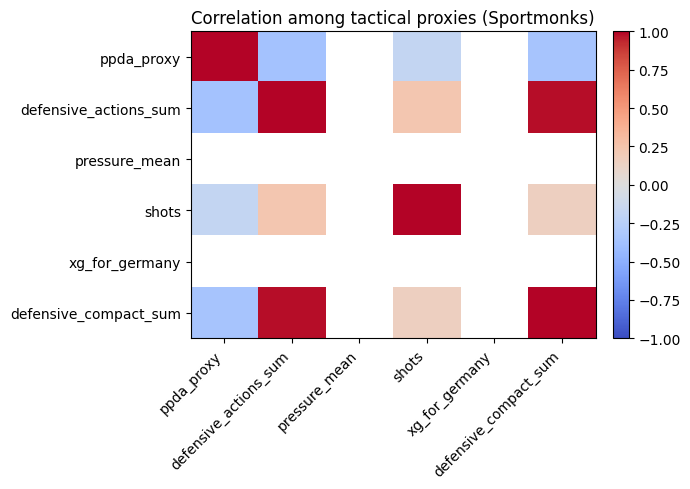

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation among tactical proxies (Sportmonks)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

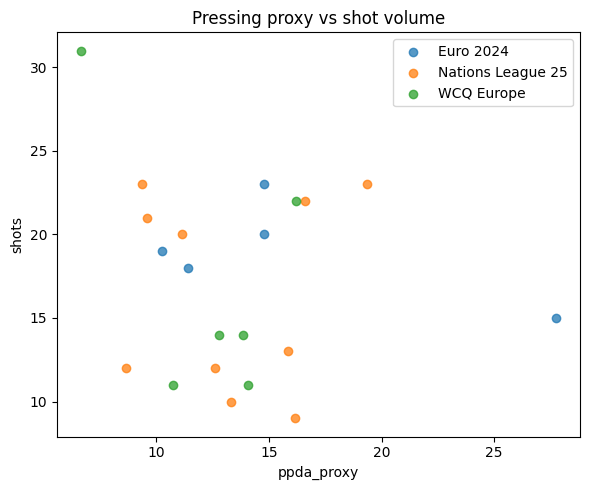

In [11]:
scatter_x, scatter_y = "ppda_proxy", "shots"
if scatter_x in m.columns and scatter_y in m.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    for comp, sub in m.groupby("competition"):
        ax.scatter(sub[scatter_x], sub[scatter_y], alpha=0.75, label=comp)
    ax.set_xlabel(scatter_x)
    ax.set_ylabel(scatter_y)
    ax.legend()
    ax.set_title("Pressing proxy vs shot volume")
    plt.tight_layout()

In [12]:
summary_path = SPORTMONKS_DIR / "germany_tactical_merged.csv"
m.to_csv(summary_path, index=False)